In [1]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt
!pip install sympy antlr4-python3-runtime==4.11.1

fatal: destination path 'reasoning-from-scratch' already exists and is not an empty directory.
/content/reasoning-from-scratch


# Infernce Time Scaling via Self Refinement

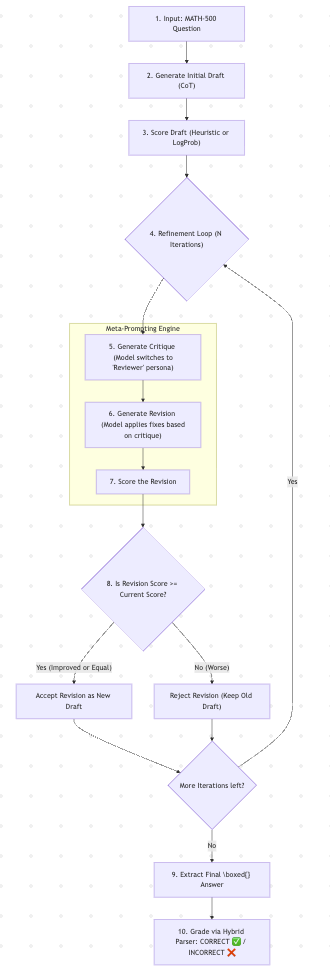

## What this script does
Extends Chapter 4 by replacing **majority voting** with **Best-of-N selection**:
generate N stochastic CoT responses, *score* each one, return the highest-scoring
answer. Same model, same sampling — the upgrade is the scoring signal.

---

## Key Concept: Best-of-N vs Self-Consistency (Ch4)

| | Chapter 4 | Chapter 5 |
|---|---|---|
| **Selects by** | Most frequent answer | Highest-scoring answer |
| **Signal** | Consensus across samples | Quality score per sample |
| **Name** | Self-Consistency / Majority Vote | Best-of-N / Rejection Sampling |

---

## 1. Scoring Method A — Heuristic (`heuristic_score`)
Fast, formatting-based, **no extra forward pass**.

| Component | Points | Condition |
|---|---|---|
| Boxed bonus | +2.0 | `\boxed{}` found — model followed instructions |
| Extract bonus | +1.0 | A number found but not in `\boxed{}` |
| Brevity bonus | +0 to 1.5 | `1.5 × exp(-len/500)` — shorter = better |

> **Weakness:** a short, well-formatted *wrong* answer can outscore a long,
> correct one. Purely surface-level.

---

## 2. Scoring Method B — Log-Probability (`avg_logprob_answer`)
Slower, model-grounded, **one forward pass per candidate**.

**Idea:** ask the model how confident it was in its own tokens.
Higher (less negative) average log-prob = model was more certain = better answer.

**Steps:**
1. Concatenate `[prompt tokens | answer tokens]` into one sequence.
2. Single forward pass → logits → `log_softmax` → log-probs.
3. Use causal offset: logits at position `i` predict token `i+1`, so the
   answer window starts at `len(prompt) - 1` (last prompt position).
4. Index into log-probs using the actual answer token IDs.
5. Return the mean log-prob across all answer tokens.

---

## 3. Best-of-N Loop (`best_of_n_vote`)
```
for each of N samples:
    generate full CoT response (temperature + top-p, same as Ch4)
    extract short answer candidate
    score with chosen method (heuristic OR logprob)
    track the highest-scoring candidate

return best_extracted
```
No early stopping (unlike Ch4 majority vote) — all N samples are always scored.

---

## 4. Evaluation Loop (`run_ch5_best_of_n_evaluation`)
```
For each problem:
  1. BUILD  — render_prompt() + "Explain step by step." (CoT trigger)
  2. SCORE  — best_of_n_vote() → pick highest-scoring of NUM_SAMPLES responses
  3. GRADE  — normalize_text_hybrid() on both sides → string compare
```

Swap `SCORING_METHOD = "heuristic"` ↔ `"logprob"` to benchmark the two approaches.

In [6]:
import torch
import math

# ── Chapter 2 utilities: hardware detection
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B
)

# ── Chapter 3 utilities: dataset, prompt formatter, answer extractor
from reasoning_from_scratch.ch03 import (
    load_math500_test,
    render_prompt,
    extract_final_candidate
)

# ── Heavy LaTeX normaliser for grading
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid

# ── Chapter 4 generation utilities: stochastic sampler + convenience wrapper
from reasoning_from_scratch.ch04 import (
    generate_text_stream_concat_flex,   # Collects streamed tokens into a single string
    generate_text_top_p_stream_cache    # The temperature + top-p streaming generator
)


# ─────────────────────────────────────────────
# 1. SCORING MECHANISMS
# ─────────────────────────────────────────────

def heuristic_score(answer, prompt=None, brevity_bonus=500.0, boxed_bonus=2.0, extract_bonus=1.0):
    """
    Scores a generated answer using hand-crafted formatting rules — no model
    forward pass required, so it's fast and cheap.

    Scoring components:
      +2.0  if a \boxed{} answer was found (model followed instructions)
      +1.0  if any number was found as a fallback (partial credit)
      +0→1.5 brevity bonus: exponential decay — shorter answers score higher,
             with the bonus halving roughly every 500 characters.
             Rewards concise, confident answers over verbose, rambling ones.

    Weakness: purely surface-level — a short, well-formatted WRONG answer
    can outscore a long, correct one. Use logprob scoring for better results.
    """
    score = 0.0

    if extract_final_candidate(answer, fallback="none"):
        score += boxed_bonus      # Model placed its answer in \boxed{} as instructed
    elif extract_final_candidate(answer, fallback="number_only"):
        score += extract_bonus    # Found a number but not in \boxed{} — partial credit

    # Brevity bonus: exp(-len/500) → 1.0 at length 0, ~0.14 at length 1000
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)

    return score


@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):
    """
    Scores a generated answer by asking: how confident was the model in its
    own tokens? Returns the average log-probability of each answer token.

    Higher (less negative) = model was more confident = better answer.

    Mechanism:
      1. Concatenate prompt + answer into one token sequence.
      2. Run a single forward pass to get logits for every position.
      3. Convert to log-probabilities via log_softmax.
      4. Isolate the slice corresponding to the answer tokens only
         (positions [len(prompt)-1 : len(full_sequence)-1]).
      5. For each answer token, look up the log-prob of the actual token
         the model chose (using the token IDs as indices into the vocab dim).
      6. Return the mean log-prob across all answer tokens.

    Why `start = len(prompt_ids) - 1`:
      In a causal LM, the logits at position i predict token i+1.
      So to get the probability of the first answer token, we need the
      logits at the last prompt position (len(prompt_ids) - 1).

    Advantage over heuristic: model-grounded — the model's own internal
    confidence is a much stronger signal than surface formatting.
    Cost: requires a full forward pass per candidate, so it's slower.
    """
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)

    # Concatenate into one sequence: [prompt tokens | answer tokens]
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Single forward pass over the full sequence
    logits = model(full_ids.unsqueeze(0)).squeeze(0)  # (seq_len, vocab_size)
    logprobs = torch.log_softmax(logits, dim=-1)       # Convert to log-probabilities

    # Define the answer token window using causal offset
    start = len(prompt_ids) - 1          # Logit position that predicts first answer token
    end   = full_ids.shape[0] - 1        # Last logit position (predicts nothing beyond EOS)

    t_idx       = torch.arange(start, end, device=device)   # Logit row indices
    next_tokens = full_ids[start + 1 : end + 1]             # The actual answer token IDs

    # Index into logprobs: for each position, get the log-prob of the chosen token
    next_token_logps = logprobs[t_idx, next_tokens]  # Shape: (num_answer_tokens,)

    return torch.mean(next_token_logps).item()


# ─────────────────────────────────────────────
# 2. BEST-OF-N ENGINE
# ─────────────────────────────────────────────

def best_of_n_vote(
    model, tokenizer, prompt, device,
    num_samples=5, temperature=0.8, top_p=0.9,
    max_new_tokens=256, scoring_method="logprob"
):
    """
    Inference-time scaling via Best-of-N (also called Rejection Sampling).

    Core idea: generate N independent stochastic responses to the same
    question, score each one, and return the answer from the highest-scoring
    response.

    Contrast with Chapter 4's self-consistency (majority voting):
      - Self-consistency picks the most FREQUENT answer → relies on consensus.
      - Best-of-N picks the highest-SCORING answer → relies on a quality signal.

    The quality signal can be swapped via `scoring_method`:
      "heuristic" — fast, formatting-based (no extra forward pass)
      "logprob"   — slower, model-confidence-based (one forward pass per sample)

    Args:
        num_samples    : N — how many candidates to generate and score.
        temperature    : Sampling diversity (0 = greedy, 0.8 = recommended).
        top_p          : Nucleus filter size per sample.
        scoring_method : Which scorer to use ("heuristic" or "logprob").

    Returns:
        The extracted answer string from the highest-scoring candidate.
    """
    best_score     = float("-inf")
    best_extracted = None

    for i in range(num_samples):

        # Generate one full CoT response using Chapter 4's stochastic sampler
        answer = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            device=device,
            max_new_tokens=max_new_tokens,
            generate_func=generate_text_top_p_stream_cache,  # Plug-in sampler
            temperature=temperature,
            top_p=top_p
        )

        # Extract the short answer candidate from \boxed{} or last number
        short = extract_final_candidate(answer)

        # Score the full response with the chosen method
        if scoring_method == "heuristic":
            score = heuristic_score(answer, prompt=prompt)
        elif scoring_method == "logprob":
            score = avg_logprob_answer(model, tokenizer, prompt, answer, device=device)
        else:
            raise ValueError(f"Unknown scoring method: {scoring_method!r}")

        print(f"   [Sample {i+1}/{num_samples}] Score: {score:>7.3f} | Extracted: {short!r}")

        # Keep track of the best-scoring candidate seen so far
        if score > best_score:
            best_score     = score
            best_extracted = short

    print(f"   -> Selected Best-of-{num_samples}: {best_extracted!r} (Score: {best_score:.3f})")
    return best_extracted


# ─────────────────────────────────────────────
# 3. EVALUATION ENGINE
# ─────────────────────────────────────────────

def run_ch5_best_of_n_evaluation(dataset_size=2):
    """
    End-to-end Chapter 5 evaluation loop.

    Pipeline per question:
      1. BUILD  — CoT prompt (render_prompt + "Explain step by step.")
      2. SCORE  — best_of_n_vote() generates NUM_SAMPLES responses and picks
                  the highest-scoring one via the chosen scoring method.
      3. GRADE  — normalize both prediction and ground truth with the hybrid
                  LaTeX parser, then compare as strings.
    """

    # ── Parser health-check ───────────────────────────────────────────────
    if normalize_text_hybrid(r"\frac{1}{2}") != "1/2":
        raise RuntimeError(
            "🚨 Hybrid parser failed. "
            "Run `!pip install antlr4-python3-runtime==4.11.1` and RESTART session."
        )

    # ── Model setup ───────────────────────────────────────────────────────
    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device).eval()

    # ── Dataset ───────────────────────────────────────────────────────────
    math_data = load_math500_test()[:dataset_size]
    num_correct = 0

    # ── Hyperparameters ───────────────────────────────────────────────────
    SCORING_METHOD = "logprob"                    # Swap to "heuristic" for the fast baseline
    PROMPT_SUFFIX  = "\n\nExplain step by step."  # CoT trigger — same as Chapter 4
    NUM_SAMPLES    = 5                            # Candidate pool size for Best-of-N

    print(f"\nStarting Chapter 5 Best-of-{NUM_SAMPLES} ({SCORING_METHOD.upper()} Scoring)...")

    for i, row in enumerate(math_data, 1):
        print(f"\n--- Question {i} ---")

        # Step 1: Build the CoT prompt
        cot_prompt = render_prompt(row["problem"]) + PROMPT_SUFFIX

        # Step 2: Generate N candidates and return the highest-scoring answer
        final_answer = best_of_n_vote(
            model, tokenizer, cot_prompt, device,
            num_samples=NUM_SAMPLES,
            temperature=0.8,
            top_p=0.9,
            scoring_method=SCORING_METHOD
        )

        # Step 3: Normalise and grade
        pred       = normalize_text_hybrid(final_answer)
        gold       = normalize_text_hybrid(row["answer"])
        is_correct = (pred == gold)
        num_correct += int(is_correct)

        print(f"\nExpected : {row['answer']}")
        print(f"Final    : {final_answer}")
        print(f"Graded   : {'CORRECT ✅' if is_correct else 'INCORRECT ❌'}")

    print(f"\nFinal Accuracy: {num_correct}/{dataset_size}")


# ── Entry point ────────────────────────────────────────────────────────────────
run_ch5_best_of_n_evaluation(dataset_size=50)

Using NVIDIA CUDA GPU
Using device: cuda
✓ qwen3/qwen3-0.6B-base.pth already up-to-date

Starting Chapter 5 Best-of-5 (LOGPROB Scoring)...

--- Question 1 ---
   [Sample 1/5] Score:  -0.089 | Extracted: '0'
   [Sample 2/5] Score:  -0.092 | Extracted: '3'
   [Sample 3/5] Score:  -0.094 | Extracted: '3'
   [Sample 4/5] Score:  -0.129 | Extracted: '0'
   [Sample 5/5] Score:  -0.138 | Extracted: '90'
   -> Selected Best-of-5: '0' (Score: -0.089)

Expected : \left( 3, \frac{\pi}{2} \right)
Final    : 0
Graded   : INCORRECT ❌

--- Question 2 ---
   [Sample 1/5] Score:  -0.218 | Extracted: '3'
   [Sample 2/5] Score:  -0.201 | Extracted: '4'
   [Sample 3/5] Score:  -0.115 | Extracted: '2'
   [Sample 4/5] Score:  -0.293 | Extracted: '9'
   [Sample 5/5] Score:  -0.160 | Extracted: '1'
   -> Selected Best-of-5: '2' (Score: -0.115)

Expected : p - q
Final    : 2
Graded   : INCORRECT ❌

--- Question 3 ---
   [Sample 1/5] Score:  -0.112 | Extracted: '3'
   [Sample 2/5] Score:  -0.153 | Extracted: '\

# Self-Refinement Loop

## What this script does
Extends Chapter 5's Best-of-N by replacing parallel sampling with **iterative
self-improvement**: generate one draft, have the model critique it, then revise
it based on that critique. Only accept the revision if it scores better.

---

## Key Concept: Self-Refinement vs Best-of-N (Ch5a) vs Self-Consistency (Ch4)

| | Ch4 Self-Consistency | Ch5a Best-of-N | Ch5b Self-Refinement |
|---|---|---|---|
| **Strategy** | N parallel samples → majority vote | N parallel samples → best score | 1 draft → critique → revision |
| **Model calls** | N | N (+ N for scoring) | 1 draft + 2 per iteration |
| **Selects by** | Frequency | Heuristic / logprob score | Iterative improvement |

---

## 1. Heuristic Scorer (`heuristic_score`)
Same fast formatting scorer from Best-of-N — used here as a **gate**
to accept or reject each revision.

| Tier | Score | Condition |
|---|---|---|
| `\boxed{}` found | +2.0 | Followed format instructions |
| Bare number found | +1.0 | Answer present, wrong format |
| Free text only | +0.0 | No extractable answer |

Plus brevity bonus: `1.5 × exp(-len/500)`

---

## 2. Two Prompt Builders

### `make_critique_prompt(raw_prompt, draft)`
Instructs the model to act as a reviewer of its own draft — find logical
errors, missing steps, arithmetic mistakes. Capped at ~120 words to stay focused.

### `make_refine_prompt(raw_prompt, draft, critique)`
Instructs the model to revise the draft using the critique, ending with `\boxed{ANSWER}`.

These two prompts form the **handoff chain**: draft → critique → refined answer.

---

## 3. Self-Refinement Loop (`self_refinement_loop`)

```
1. Generate initial draft  (render_prompt + "Explain step by step.")
       ↓
2. For each iteration:
   Call 1 → make_critique_prompt  → model → critique   (max 256 tokens)
   Call 2 → make_refine_prompt    → model → revision   (max 512 tokens)
       ↓
   heuristic_score(revision) >= heuristic_score(current)?
     YES → accept revision, update current
     NO  → reject revision, keep current
       ↓
3. Return final extracted answer
```

> Temperature is **0.7** (lower than Ch4's 0.8) — want focused revision,
> not exploratory diversity.

---

## 4. Evaluation Loop (`run_ch5_evaluation`)

```
For each problem:
  1. REFINE  — self_refinement_loop() runs draft → critique → revision
  2. GRADE   — normalize_text_hybrid() on both sides → string compare
```

`iterations=1` means one critique+revision cycle per question. Increasing
it runs more cycles — each one a chance to further improve the answer.

In [2]:
import torch
import math
from collections import Counter

# ── Chapter 2 utilities: hardware detection
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B
)

# ── Chapter 3 utilities: dataset, prompt formatter, answer extractor
from reasoning_from_scratch.ch03 import (
    load_math500_test,
    render_prompt,
    extract_final_candidate
)

# ── Chapter 4 generation utilities: stochastic sampler + convenience wrapper
from reasoning_from_scratch.ch04 import (
    generate_text_stream_concat_flex,   # Collects streamed tokens into a single string
    generate_text_top_p_stream_cache    # Temperature + top-p streaming generator
)

# ── Heavy LaTeX normaliser for grading
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid


# ─────────────────────────────────────────────
# 1. HEURISTIC SCORER
# ─────────────────────────────────────────────

def heuristic_score(
    answer,
    prompt=None,
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0
):
    """
    Scores a generated answer using fast, formatting-based rules.
    No model forward pass — used here to decide whether to keep a revision.

    Scoring tiers (mutually exclusive, checked top-down):
      +2.0  (\boxed{} found)     — model followed the answer format exactly
      +1.0  (bare number found)  — answer present but not in \boxed{}
      +0.0  (only free text)     — no extractable answer found at all

    Plus a continuous brevity bonus:
      +0→1.5 via 1.5 × exp(-len(answer) / 500)
      → ~1.5 at length 0, ~0.82 at length 500, ~0.14 at length 1000
      Rewards concise answers; penalises verbose rambling.

    Used in self_refinement_loop as a gating signal:
    a revision is only accepted if its score >= the draft's score.
    """
    score = 0.0

    if extract_final_candidate(answer, fallback="none"):
        score += boxed_bonus          # Best case: \boxed{} present
    elif extract_final_candidate(answer, fallback="number_only"):
        score += extract_bonus        # Acceptable: bare number found
    elif extract_final_candidate(answer, fallback="number_then_full"):
        score += fulltext_bonus       # Worst case: just a wall of text (scores 0)

    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score


# ─────────────────────────────────────────────
# 2. PROMPT BUILDERS FOR SELF-REFINEMENT
# ─────────────────────────────────────────────

def make_critique_prompt(raw_prompt, draft):
    """
    Builds the CRITIQUE prompt: shown to the model alongside the original
    question and the draft answer.

    Instructs the model to act as a reviewer and identify:
      - Logical errors
      - Missing steps
      - Arithmetic mistakes

    Output is intentionally short (~120 words max) to stay focused.
    The critique is then fed into make_refine_prompt() as context.
    """
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan (under ~120 words).\nCritique:"
    )


def make_refine_prompt(raw_prompt, draft, critique):
    """
    Builds the REFINEMENT prompt: shown to the model alongside the original
    question, the draft, and the critique generated above.

    Instructs the model to produce a revised answer that:
      - Addresses the issues raised in the critique
      - Is concise
      - Ends with \\boxed{ANSWER} so the extractor can find it

    This is the second of the two model calls in each refinement iteration.
    """
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\nRevised answer:"
    )


# ─────────────────────────────────────────────
# 3. SELF-REFINEMENT LOOP
# ─────────────────────────────────────────────

def self_refinement_loop(
    model, tokenizer, raw_prompt, device,
    iterations=1, temperature=0.7, top_p=0.9
):
    """
    Inference-time scaling via Self-Refinement (Madaan et al., 2023).

    Core idea: instead of generating N independent responses and picking
    the best (Best-of-N), generate ONE response and iteratively improve it
    by having the model critique its own work and then revise based on that
    critique.

    Each iteration consists of two model calls:
      Call 1 — CRITIQUE : "What is wrong with this draft?"
      Call 2 — REVISION : "Fix the issues identified in the critique."

    The revision is accepted only if its heuristic score >= the current
    draft's score — this prevents a bad revision from making things worse.

    Per-iteration flow:
    ┌─────────────────────────────────────────────────────────┐
    │  current_full (draft)                                   │
    │       ↓                                                 │
    │  make_critique_prompt → model → critique_full           │
    │       ↓                                                 │
    │  make_refine_prompt(draft, critique) → model → revised  │
    │       ↓                                                 │
    │  heuristic_score(revised) >= heuristic_score(current)?  │
    │    YES → accept revised as new current                  │
    │    NO  → keep current (reject the revision)             │
    └─────────────────────────────────────────────────────────┘

    Args:
        raw_prompt : The bare math problem text (no prompt template applied yet).
        iterations : How many critique→revise cycles to run (default 1).
        temperature: Lower than Chapter 4 (0.7) — we want focused revisions,
                     not exploratory diversity.

    Returns:
        The extracted answer string from the best accepted response.
    """

    # ── Step 1: Generate the initial draft ────────────────────────────────
    # Apply the standard Chapter 3 prompt template + CoT trigger
    base_prompt = render_prompt(raw_prompt) + "\n\nExplain step by step."

    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=base_prompt,
        device=device,
        max_new_tokens=512,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p
    )

    current_extracted = extract_final_candidate(current_full)
    current_score     = heuristic_score(current_full)

    print(f"   [Draft] Extracted: {current_extracted!r} (Score: {current_score:.3f})")

    # ── Step 2: Iterative critique → revision cycles ───────────────────────
    for it in range(iterations):

        # Call 1: Ask the model to critique the current draft
        critique_prompt = make_critique_prompt(raw_prompt, current_full)
        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=256,   # Short — critique should be concise
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p
        )
        # Print a snippet so we can see what the model found to criticise
        print(f"   [Critique] {critique_full.strip()[:100]}...")

        # Call 2: Ask the model to revise based on the critique
        refine_prompt = make_refine_prompt(raw_prompt, current_full, critique_full)
        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=512,   # Same budget as the draft
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p
        )

        revised_extracted = extract_final_candidate(revised_full)
        revised_score     = heuristic_score(revised_full)

        print(f"   [Revision {it+1}] Extracted: {revised_extracted!r} (Score: {revised_score:.3f})")

        # Gate: only accept the revision if it scores at least as well as the draft
        if revised_score >= current_score:
            current_full      = revised_full
            current_extracted = revised_extracted
            current_score     = revised_score
        else:
            print("   -> Revision scored lower than draft. Rejecting revision.")

    return current_extracted


# ─────────────────────────────────────────────
# 4. EVALUATION ENGINE
# ─────────────────────────────────────────────

def run_ch5_evaluation(dataset_size=2):
    """
    End-to-end Chapter 5 evaluation loop.

    Pipeline per question:
      1. BUILD   — pass the raw problem through self_refinement_loop
                   (prompt templating happens inside the loop)
      2. REFINE  — draft → critique → revision, gated by heuristic score
      3. GRADE   — normalize_text_hybrid on both sides → string compare
    """

    # ── Parser health-check ───────────────────────────────────────────────
    if normalize_text_hybrid(r"\frac{1}{2}") != "1/2":
        raise RuntimeError(
            "🚨 Hybrid parser failed. "
            "Run `!pip install antlr4-python3-runtime==4.11.1` and RESTART session."
        )

    # ── Model setup ───────────────────────────────────────────────────────
    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device).eval()

    # ── Dataset ───────────────────────────────────────────────────────────
    math_data = load_math500_test()[:dataset_size]
    num_correct = 0

    print("\nStarting Chapter 5 Self-Refinement...")

    for i, row in enumerate(math_data, 1):
        print(f"\n--- Question {i} ---")

        # Run the full draft → critique → revision pipeline for this problem.
        # Raw problem text is passed in; prompt templating happens inside the loop.
        final_answer = self_refinement_loop(
            model, tokenizer,
            raw_prompt=row["problem"],
            device=device,
            iterations=1,    # One critique+revision cycle per question
            temperature=0.7, # Lower than Ch4 — focused revision, not exploration
            top_p=0.9
        )

        # Normalise and grade
        pred       = normalize_text_hybrid(final_answer)
        gold       = normalize_text_hybrid(row["answer"])
        is_correct = (pred == gold)
        num_correct += int(is_correct)

        print(f"\nExpected : {row['answer']}")
        print(f"Final    : {final_answer}")
        print(f"Graded   : {'CORRECT ✅' if is_correct else 'INCORRECT ❌'}")

    print(f"\nFinal Accuracy: {num_correct}/{dataset_size}")


# ── Entry point ────────────────────────────────────────────────────────────────
run_ch5_evaluation(dataset_size=50)

Using NVIDIA CUDA GPU
Using device: cuda
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)

Starting Chapter 5 Self-Refinement...

--- Question 1 ---
   [Draft] Extracted: '3, \\frac{\\pi}{2}' (Score: 2.171)
   [Critique] The solution to the polar coordinate conversion problem was accurate, but the explanation could be c...
   [Revision 1] Extracted: '2' (Score: 1.106)
   -> Revision scored lower than draft. Rejecting revision.

Expected : \left( 3, \frac{\pi}{2} \right)
Final    : 3, \frac{\pi}{2}
Graded   : INCORRECT ❌

--- Question 2 ---
   [Draft] Extracted: '1' (Score: 1.174)
   [Critique] The provided draft answer attempts to express the double sum \(\sum_{j=1}^\infty \sum_{k=1}^\infty \...
   [Revision 1] Extracted: '\\text{The double sum can be expressed in terms of } p \\text{ and } q \\text{ by following the steps outlined above.}' (Score: 3.171)

Expected : p - q
Final    : \text{The double sum can be expressed in terms of } p \text{ and } q \text{ by following the steps outli